# MDCE Hardening Add-on

This notebook does **not** rerun raw data ingestion. It starts from the completed training table:

`/content/drive/MyDrive/ibm_project_stuff/MDCE/data/processed/pit_training_rows.parquet`

Use this after the main notebook has completed through Step 12 or Step 15.

It performs extra proof-layer work: model leaderboard, baselines, threshold sweep, calibration, temporal validation, multi-horizon training, robustness stress tests, learning curve, holdout permutation importance, weak-spot analysis, and best-model export.


## 1. Mount Drive

Colab must mount Drive to access the MDCE project folder. The code itself is locked to `/content/drive/MyDrive/ibm_project_stuff/MDCE` and does not search the rest of Drive.


In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install Dependencies


In [3]:
%pip install -q pandas numpy pyarrow scikit-learn matplotlib seaborn joblib


## 3. Run Hardening

This can take time because it trains multiple models and runs permutation importance, but it avoids rebuilding the SQLite database.


In [4]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


DRIVE_ROOT = Path("/content/drive/MyDrive/ibm_project_stuff/MDCE")
if not DRIVE_ROOT.exists():
    raise FileNotFoundError(
        f"Expected project folder not found: {DRIVE_ROOT}. "
        "This hardening add-on is folder-locked and will not scan MyDrive."
    )

PROCESSED_DIR = DRIVE_ROOT / "data" / "processed"
REPORT_DIR = DRIVE_ROOT / "outputs" / "reports"
CHART_DIR = DRIVE_ROOT / "outputs" / "charts"
MODEL_DIR = DRIVE_ROOT / "outputs" / "models"

for folder in [REPORT_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

training_path = PROCESSED_DIR / "pit_training_rows.parquet"
if not training_path.exists():
    raise FileNotFoundError(
        f"Missing training table: {training_path}. "
        "Run the main notebook through Step 9 first."
    )

print("Loading training table:", training_path)
training = pd.read_parquet(training_path)
print("training shape:", training.shape)

target = "pit_within_3_laps"
feature_cols_numeric = [
    "lap",
    "lap_time_s",
    "position",
    "grid",
    "tyre_age",
    "stint",
    "air_temp",
    "track_temp",
    "humidity",
    "pressure",
    "rainfall",
    "wind_speed",
    "wind_direction",
    "rolling_lap_avg_3",
    "rolling_lap_avg_5",
    "lap_time_delta",
    "degradation_3",
    "degradation_5",
    "lap_progress_ratio",
]
feature_cols_categorical = ["tyre_compound", "driver_code", "circuit"]
feature_cols = feature_cols_numeric + feature_cols_categorical

missing_cols = [col for col in feature_cols + [target, "year"] if col not in training.columns]
if missing_cols:
    raise ValueError(f"Training table missing required columns: {missing_cols}")

ml_df = training.dropna(subset=[target]).copy()
train_df = ml_df[ml_df["year"] <= 2022].copy()
test_df = ml_df[ml_df["year"] == 2023].copy()

if train_df.empty or test_df.empty:
    raise RuntimeError("Need train years <=2022 and test year 2023 in pit_training_rows.parquet.")

X_train = train_df[feature_cols]
y_train = train_df[target].astype(int)
X_test = test_df[feature_cols]
y_test = test_df[target].astype(int)

print("train rows:", len(train_df), "test rows:", len(test_df))
print("train positive rate:", round(float(y_train.mean()), 4), "test positive rate:", round(float(y_test.mean()), 4))


def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    print("wrote:", path)


def make_preprocess(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), feature_cols_numeric),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), feature_cols_categorical),
        ]
    )


def evaluate_scores(name, y_true, scores, threshold_value=0.50):
    labels = (scores >= threshold_value).astype(int)
    return {
        "model": name,
        "threshold": float(threshold_value),
        "rows": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "predicted_positive_rate": float(np.mean(labels)),
        "accuracy": float(accuracy_score(y_true, labels)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, labels)),
        "precision": float(precision_score(y_true, labels, zero_division=0)),
        "recall": float(recall_score(y_true, labels, zero_division=0)),
        "f1": float(f1_score(y_true, labels, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, labels)),
        "brier_score": float(brier_score_loss(y_true, scores)),
        "roc_auc": float(roc_auc_score(y_true, scores)) if len(set(y_true)) == 2 else None,
        "average_precision": float(average_precision_score(y_true, scores)) if len(set(y_true)) == 2 else None,
    }


def evaluate_model(name, fitted_model, X_eval, y_eval, threshold_value=0.50):
    scores = fitted_model.predict_proba(X_eval)[:, 1]
    return evaluate_scores(name, np.asarray(y_eval), scores, threshold_value), scores


print("\nSTEP A: candidate model leaderboard")
candidate_specs = [
    (
        "random_forest_250_balanced",
        Pipeline(
            steps=[
                ("preprocess", make_preprocess(scale_numeric=False)),
                ("classifier", RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1)),
            ]
        ),
    ),
    (
        "extra_trees_300_balanced",
        Pipeline(
            steps=[
                ("preprocess", make_preprocess(scale_numeric=False)),
                ("classifier", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1)),
            ]
        ),
    ),
    (
        "logistic_regression_balanced",
        Pipeline(
            steps=[
                ("preprocess", make_preprocess(scale_numeric=True)),
                ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", solver="saga", n_jobs=-1, random_state=42)),
            ]
        ),
    ),
]

leaderboard_rows = []
trained_models = {}
for model_name, model in candidate_specs:
    print("training:", model_name)
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    row, _ = evaluate_model(model_name, model, X_test, y_test, 0.50)
    leaderboard_rows.append(row)

leaderboard_df = pd.DataFrame(leaderboard_rows).sort_values(["average_precision", "f1"], ascending=False)
leaderboard_df.to_csv(REPORT_DIR / "advanced_model_leaderboard.csv", index=False)
best_model_name = str(leaderboard_df.iloc[0]["model"])
best_model = trained_models[best_model_name]
best_model_path = MODEL_DIR / "pit_window_best_model.joblib"
joblib.dump(best_model, best_model_path)
print("best model:", best_model_name)
print("saved:", best_model_path)
print(leaderboard_df.to_string(index=False))

print("\nSTEP B: baseline and threshold discipline")
best_row, best_scores = evaluate_model(best_model_name, best_model, X_test, y_test, 0.50)
baseline_rows = [
    best_row,
    evaluate_scores("always_no_pit_baseline", y_test.to_numpy(), np.full(len(y_test), y_train.mean()), 0.50),
    evaluate_scores("simple_tyre_age_ge_14_rule", y_test.to_numpy(), (test_df["tyre_age"].fillna(-1).to_numpy() >= 14).astype(float), 0.50),
    evaluate_scores("simple_degradation_ge_0_15_rule", y_test.to_numpy(), (test_df["degradation_3"].fillna(0).to_numpy() >= 0.15).astype(float), 0.50),
]
baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(REPORT_DIR / "proof_baseline_comparison.csv", index=False)

threshold_rows = []
for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2):
    threshold_rows.append(evaluate_scores(best_model_name, y_test.to_numpy(), best_scores, float(threshold)))
threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(REPORT_DIR / "proof_threshold_sweep.csv", index=False)
best_threshold = threshold_df.sort_values(["f1", "precision"], ascending=False).iloc[0].to_dict()
print("best threshold by F1:", best_threshold)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Proof Audit: Threshold Tradeoff")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "proof_threshold_tradeoff.png", dpi=160)
plt.close()

print("\nSTEP C: calibration audit")
calibration_df = pd.DataFrame({"predicted_probability": best_scores, "actual": y_test.to_numpy()})
calibration_df["probability_bin"] = pd.cut(calibration_df["predicted_probability"], bins=np.linspace(0, 1, 11), include_lowest=True)
calibration_summary = (
    calibration_df.groupby("probability_bin", observed=False)
    .agg(rows=("actual", "size"), avg_predicted_probability=("predicted_probability", "mean"), actual_positive_rate=("actual", "mean"))
    .reset_index()
)
calibration_summary["probability_bin"] = calibration_summary["probability_bin"].astype(str)
calibration_summary["abs_calibration_gap"] = (
    calibration_summary["avg_predicted_probability"] - calibration_summary["actual_positive_rate"]
).abs()
non_empty_calibration = calibration_summary[calibration_summary["rows"] > 0].copy()
ece = float((non_empty_calibration["rows"] * non_empty_calibration["abs_calibration_gap"]).sum() / max(1, non_empty_calibration["rows"].sum()))
calibration_summary.to_csv(REPORT_DIR / "proof_calibration_bins.csv", index=False)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(non_empty_calibration["avg_predicted_probability"], non_empty_calibration["actual_positive_rate"], marker="o", label=best_model_name)
plt.title("Proof Audit: Probability Calibration")
plt.xlabel("Average predicted probability")
plt.ylabel("Actual positive rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "proof_calibration_curve.png", dpi=160)
plt.close()

print("\nSTEP D: temporal validation and learning curve")
temporal_rows = []
temporal_splits = [
    {"split": "train_2021_test_2022", "train_years": [2021], "test_year": 2022},
    {"split": "train_2021_2022_test_2023", "train_years": [2021, 2022], "test_year": 2023},
]
for split in temporal_splits:
    split_train = ml_df[ml_df["year"].isin(split["train_years"])].copy()
    split_test = ml_df[ml_df["year"].eq(split["test_year"])].copy()
    if split_train.empty or split_test.empty:
        continue
    temporal_model = Pipeline(
        steps=[
            ("preprocess", make_preprocess(False)),
            ("classifier", RandomForestClassifier(n_estimators=180, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1)),
        ]
    )
    temporal_model.fit(split_train[feature_cols], split_train[target].astype(int))
    row, _ = evaluate_model(split["split"], temporal_model, split_test[feature_cols], split_test[target].astype(int), 0.50)
    row["train_years"] = ",".join(str(year) for year in split["train_years"])
    row["test_year"] = split["test_year"]
    temporal_rows.append(row)
temporal_df = pd.DataFrame(temporal_rows)
temporal_df.to_csv(REPORT_DIR / "advanced_temporal_validation.csv", index=False)

learning_rows = []
for frac in [0.25, 0.50, 0.75, 1.00]:
    subset = train_df.sample(frac=frac, random_state=42) if frac < 1.0 else train_df
    learning_model = Pipeline(
        steps=[
            ("preprocess", make_preprocess(False)),
            ("classifier", RandomForestClassifier(n_estimators=120, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1)),
        ]
    )
    learning_model.fit(subset[feature_cols], subset[target].astype(int))
    row, _ = evaluate_model(f"train_fraction_{frac:.2f}", learning_model, X_test, y_test, 0.50)
    row["train_fraction"] = frac
    row["train_rows"] = int(len(subset))
    learning_rows.append(row)
learning_df = pd.DataFrame(learning_rows)
learning_df.to_csv(REPORT_DIR / "advanced_learning_curve.csv", index=False)

plt.figure(figsize=(9, 5))
plt.plot(learning_df["train_rows"], learning_df["average_precision"], marker="o", label="Average precision")
plt.plot(learning_df["train_rows"], learning_df["f1"], marker="o", label="F1")
plt.title("Advanced Proof: Learning Curve Against 2023 Holdout")
plt.xlabel("Training rows")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "advanced_learning_curve.png", dpi=160)
plt.close()

print("\nSTEP E: multi-horizon training")
multi_rows = []
for horizon_target in ["pit_within_1_laps", "pit_within_2_laps", "pit_within_3_laps", "pit_within_5_laps"]:
    horizon_train = train_df.dropna(subset=[horizon_target])
    horizon_test = test_df.dropna(subset=[horizon_target])
    horizon_model = Pipeline(
        steps=[
            ("preprocess", make_preprocess(False)),
            ("classifier", RandomForestClassifier(n_estimators=160, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1)),
        ]
    )
    horizon_model.fit(horizon_train[feature_cols], horizon_train[horizon_target].astype(int))
    row, _ = evaluate_model(horizon_target, horizon_model, horizon_test[feature_cols], horizon_test[horizon_target].astype(int), 0.50)
    row["horizon_target"] = horizon_target
    multi_rows.append(row)
multi_df = pd.DataFrame(multi_rows)
multi_df.to_csv(REPORT_DIR / "advanced_multi_horizon_metrics.csv", index=False)

print("\nSTEP F: robustness stress tests")
stress_tests = {
    "normal": [],
    "weather_missing": ["air_temp", "track_temp", "humidity", "pressure", "rainfall", "wind_speed", "wind_direction"],
    "tyre_signal_missing": ["tyre_age", "tyre_compound", "stint"],
    "degradation_missing": ["rolling_lap_avg_3", "rolling_lap_avg_5", "lap_time_delta", "degradation_3", "degradation_5"],
    "position_context_missing": ["position", "grid"],
}
stress_rows = []
for stress_name, columns_to_mask in stress_tests.items():
    stress_X = X_test.copy()
    for col in columns_to_mask:
        if col in stress_X.columns:
            stress_X[col] = np.nan
    row, _ = evaluate_model(stress_name, best_model, stress_X, y_test, 0.50)
    row["masked_columns"] = ", ".join(columns_to_mask)
    stress_rows.append(row)
stress_df = pd.DataFrame(stress_rows)
stress_df.to_csv(REPORT_DIR / "advanced_robustness_stress_tests.csv", index=False)

plt.figure(figsize=(9, 5))
plot_stress = stress_df[["model", "average_precision", "f1"]].melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_stress, x="model", y="score", hue="metric")
plt.title("Advanced Proof: Robustness Stress Tests")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(CHART_DIR / "advanced_robustness_stress_tests.png", dpi=160)
plt.close()

print("\nSTEP G: holdout permutation importance")
sample_size = min(3000, len(X_test))
permutation_sample = X_test.sample(n=sample_size, random_state=42)
permutation_target = y_test.loc[permutation_sample.index]
permutation_result = permutation_importance(
    best_model,
    permutation_sample,
    permutation_target,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)
permutation_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)
permutation_df.to_csv(REPORT_DIR / "advanced_permutation_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=permutation_df.head(15), x="importance_mean", y="feature")
plt.title("Advanced Proof: Holdout Permutation Importance")
plt.xlabel("Mean AP decrease after permutation")
plt.tight_layout()
plt.savefig(CHART_DIR / "advanced_permutation_importance.png", dpi=160)
plt.close()

print("\nSTEP H: weak spots and reports")
if (REPORT_DIR / "ml_decision_events_2023.csv").exists():
    events_df = pd.read_csv(REPORT_DIR / "ml_decision_events_2023.csv")
else:
    events_df = pd.DataFrame()

if not events_df.empty:
    circuit_metrics = (
        events_df.groupby("circuit")
        .agg(
            events=("abs_lap_error", "size"),
            mean_abs_lap_error=("abs_lap_error", "mean"),
            median_abs_lap_error=("abs_lap_error", "median"),
            within_3_lap_rate=("abs_lap_error", lambda s: float((s <= 3).mean())),
            within_5_lap_rate=("abs_lap_error", lambda s: float((s <= 5).mean())),
        )
        .reset_index()
        .sort_values(["mean_abs_lap_error", "events"], ascending=[False, False])
    )
    driver_metrics = (
        events_df.groupby("driver_code")
        .agg(
            events=("abs_lap_error", "size"),
            mean_abs_lap_error=("abs_lap_error", "mean"),
            median_abs_lap_error=("abs_lap_error", "median"),
            within_3_lap_rate=("abs_lap_error", lambda s: float((s <= 3).mean())),
        )
        .reset_index()
        .sort_values(["mean_abs_lap_error", "events"], ascending=[False, False])
    )
else:
    circuit_metrics = pd.DataFrame()
    driver_metrics = pd.DataFrame()

circuit_metrics.to_csv(REPORT_DIR / "proof_circuit_event_metrics.csv", index=False)
driver_metrics.to_csv(REPORT_DIR / "proof_driver_event_metrics.csv", index=False)

if not circuit_metrics.empty:
    plot_circuit = circuit_metrics.head(15).sort_values("mean_abs_lap_error")
    plt.figure(figsize=(10, 6))
    plt.barh(plot_circuit["circuit"], plot_circuit["mean_abs_lap_error"])
    plt.title("Proof Audit: Highest Mean Absolute Lap Error By Circuit")
    plt.xlabel("Mean absolute lap error")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "proof_circuit_error_profile.png", dpi=160)
    plt.close()

train_keys = set(map(tuple, train_df[["raceId", "driverId", "lap"]].astype(str).to_numpy()))
test_keys = set(map(tuple, test_df[["raceId", "driverId", "lap"]].astype(str).to_numpy()))
leakage_checks = {
    "train_test_row_overlap_count": len(train_keys.intersection(test_keys)),
    "train_test_race_overlap_count": len(set(train_df["raceId"].astype(str)).intersection(set(test_df["raceId"].astype(str)))),
    "negative_laps_until_next_pit_rows": int((training["laps_until_next_pit"] < 0).sum()),
    "missing_target_rows": int(training[target].isna().sum()),
}

advanced_hardening = {
    "best_model": leaderboard_df.iloc[0].to_dict(),
    "leaderboard": leaderboard_df.to_dict(orient="records"),
    "baseline_comparison": baseline_df.to_dict(orient="records"),
    "best_threshold_by_f1": best_threshold,
    "expected_calibration_error": ece,
    "temporal_validation": temporal_df.to_dict(orient="records"),
    "multi_horizon": multi_df.to_dict(orient="records"),
    "stress_tests": stress_df.to_dict(orient="records"),
    "learning_curve": learning_df.to_dict(orient="records"),
    "top_permutation_features": permutation_df.head(20).to_dict(orient="records"),
    "leakage_checks": leakage_checks,
}
write_json(REPORT_DIR / "advanced_model_hardening.json", advanced_hardening)
write_json(REPORT_DIR / "mdce_proof_quality_audit.json", advanced_hardening)

report_lines = [
    "# MDCE Advanced Model Hardening",
    "",
    "## Model Location",
    "",
    f"- Best model: `{best_model_path}`",
    f"- Best model family: `{best_model_name}`",
    "",
    "## Model Leaderboard",
    "",
    "| Model | AP | ROC-AUC | F1 | Precision | Recall | Brier |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
for _, row in leaderboard_df.iterrows():
    report_lines.append(f"| {row['model']} | {row['average_precision']:.3f} | {row['roc_auc']:.3f} | {row['f1']:.3f} | {row['precision']:.3f} | {row['recall']:.3f} | {row['brier_score']:.3f} |")

report_lines += [
    "",
    "## Best Threshold",
    "",
    f"- Threshold: `{best_threshold['threshold']}`",
    f"- F1: `{best_threshold['f1']:.3f}`",
    f"- Precision: `{best_threshold['precision']:.3f}`",
    f"- Recall: `{best_threshold['recall']:.3f}`",
    "",
    "## Calibration",
    "",
    f"- Expected calibration error: `{ece:.3f}`",
    "",
    "## Temporal Validation",
    "",
    "| Split | AP | ROC-AUC | F1 | Precision | Recall |",
    "|---|---:|---:|---:|---:|---:|",
]
for _, row in temporal_df.iterrows():
    report_lines.append(f"| {row['model']} | {row['average_precision']:.3f} | {row['roc_auc']:.3f} | {row['f1']:.3f} | {row['precision']:.3f} | {row['recall']:.3f} |")

report_lines += [
    "",
    "## Multi-Horizon Targets",
    "",
    "| Target | AP | ROC-AUC | F1 | Precision | Recall |",
    "|---|---:|---:|---:|---:|---:|",
]
for _, row in multi_df.iterrows():
    report_lines.append(f"| {row['horizon_target']} | {row['average_precision']:.3f} | {row['roc_auc']:.3f} | {row['f1']:.3f} | {row['precision']:.3f} | {row['recall']:.3f} |")

report_lines += [
    "",
    "## Robustness Stress Tests",
    "",
    "| Test | AP | F1 | Precision | Recall | Masked columns |",
    "|---|---:|---:|---:|---:|---|",
]
for _, row in stress_df.iterrows():
    report_lines.append(f"| {row['model']} | {row['average_precision']:.3f} | {row['f1']:.3f} | {row['precision']:.3f} | {row['recall']:.3f} | {row['masked_columns']} |")

report_lines += [
    "",
    "## Leakage Checks",
    "",
]
for key, value in leakage_checks.items():
    report_lines.append(f"- `{key}`: `{value}`")

report_lines += [
    "",
    "## Top Holdout Permutation Features",
    "",
]
for _, row in permutation_df.head(10).iterrows():
    report_lines.append(f"- `{row['feature']}`: mean AP decrease `{row['importance_mean']:.4f}`")

report_lines += [
    "",
    "## Files Written",
    "",
    f"- `{REPORT_DIR / 'advanced_model_leaderboard.csv'}`",
    f"- `{REPORT_DIR / 'proof_baseline_comparison.csv'}`",
    f"- `{REPORT_DIR / 'proof_threshold_sweep.csv'}`",
    f"- `{REPORT_DIR / 'proof_calibration_bins.csv'}`",
    f"- `{REPORT_DIR / 'advanced_temporal_validation.csv'}`",
    f"- `{REPORT_DIR / 'advanced_multi_horizon_metrics.csv'}`",
    f"- `{REPORT_DIR / 'advanced_robustness_stress_tests.csv'}`",
    f"- `{REPORT_DIR / 'advanced_learning_curve.csv'}`",
    f"- `{REPORT_DIR / 'advanced_permutation_importance.csv'}`",
    f"- `{REPORT_DIR / 'advanced_model_hardening.json'}`",
    f"- `{CHART_DIR / 'proof_threshold_tradeoff.png'}`",
    f"- `{CHART_DIR / 'proof_calibration_curve.png'}`",
    f"- `{CHART_DIR / 'advanced_learning_curve.png'}`",
    f"- `{CHART_DIR / 'advanced_robustness_stress_tests.png'}`",
    f"- `{CHART_DIR / 'advanced_permutation_importance.png'}`",
]

(REPORT_DIR / "advanced_model_hardening.md").write_text("\n".join(report_lines), encoding="utf-8")
(REPORT_DIR / "mdce_proof_quality_audit.md").write_text("\n".join(report_lines), encoding="utf-8")

print("\nHARDENING COMPLETE")
print("Best model:", best_model_name)
print("Best model path:", best_model_path)
print("Report:", REPORT_DIR / "advanced_model_hardening.md")
print("Charts:", CHART_DIR)


Loading training table: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/processed/pit_training_rows.parquet
training shape: (40867, 32)
train rows: 26183 test rows: 14684
train positive rate: 0.2092 test positive rate: 0.2217

STEP A: candidate model leaderboard
training: random_forest_250_balanced
training: extra_trees_300_balanced
training: logistic_regression_balanced
best model: random_forest_250_balanced
saved: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_best_model.joblib
                       model  threshold  rows  positive_rate  predicted_positive_rate  accuracy  balanced_accuracy  precision   recall       f1      mcc  brier_score  roc_auc  average_precision
  random_forest_250_balanced        0.5 14684        0.22167                 0.156837  0.893762           0.793767   0.867998 0.614132 0.719323 0.671100     0.090487 0.888453           0.812555
    extra_trees_300_balanced        0.5 14684        0.22167                 0.211591  0.847317    

## 4. View Key Outputs


Best model: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_best_model.joblib


# MDCE Advanced Model Hardening

## Model Location

- Best model: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_best_model.joblib`
- Best model family: `random_forest_250_balanced`

## Model Leaderboard

| Model | AP | ROC-AUC | F1 | Precision | Recall | Brier |
|---|---:|---:|---:|---:|---:|---:|
| random_forest_250_balanced | 0.813 | 0.888 | 0.719 | 0.868 | 0.614 | 0.090 |
| extra_trees_300_balanced | 0.734 | 0.850 | 0.648 | 0.663 | 0.633 | 0.122 |
| logistic_regression_balanced | 0.437 | 0.718 | 0.455 | 0.389 | 0.548 | 0.202 |

## Best Threshold

- Threshold: `0.45`
- F1: `0.724`
- Precision: `0.826`
- Recall: `0.644`

## Calibration

- Expected calibration error: `0.071`

## Temporal Validation

| Split | AP | ROC-AUC | F1 | Precision | Recall |
|---|---:|---:|---:|---:|---:|
| train_2021_test_2022 | 0.789 | 0.879 | 0.687 | 0.806 | 0.599 |
| train_2021_2022_test_2023 | 0.813 | 0.889 | 0.722 | 0.871 | 0.617 |

## Multi-Horizon Targets

| Target | AP | ROC-AUC | F1 | Precision | Recall |
|---|---:|---:|---:|---:|---:|
| pit_within_1_laps | 0.805 | 0.919 | 0.743 | 0.856 | 0.656 |
| pit_within_2_laps | 0.800 | 0.901 | 0.724 | 0.865 | 0.623 |
| pit_within_3_laps | 0.812 | 0.888 | 0.723 | 0.870 | 0.619 |
| pit_within_5_laps | 0.839 | 0.876 | 0.729 | 0.855 | 0.635 |

## Robustness Stress Tests

| Test | AP | F1 | Precision | Recall | Masked columns |
|---|---:|---:|---:|---:|---|
| normal | 0.813 | 0.719 | 0.868 | 0.614 |  |
| weather_missing | 0.820 | 0.719 | 0.884 | 0.606 | air_temp, track_temp, humidity, pressure, rainfall, wind_speed, wind_direction |
| tyre_signal_missing | 0.752 | 0.662 | 0.698 | 0.629 | tyre_age, tyre_compound, stint |
| degradation_missing | 0.774 | 0.657 | 0.903 | 0.516 | rolling_lap_avg_3, rolling_lap_avg_5, lap_time_delta, degradation_3, degradation_5 |
| position_context_missing | 0.810 | 0.719 | 0.874 | 0.611 | position, grid |

## Leakage Checks

- `train_test_row_overlap_count`: `0`
- `train_test_race_overlap_count`: `0`
- `negative_laps_until_next_pit_rows`: `0`
- `missing_target_rows`: `0`

## Top Holdout Permutation Features

- `lap_progress_ratio`: mean AP decrease `0.4049`
- `tyre_age`: mean AP decrease `0.0556`
- `tyre_compound`: mean AP decrease `0.0358`
- `lap`: mean AP decrease `0.0178`
- `lap_time_delta`: mean AP decrease `0.0174`
- `lap_time_s`: mean AP decrease `0.0134`
- `degradation_5`: mean AP decrease `0.0090`
- `stint`: mean AP decrease `0.0087`
- `degradation_3`: mean AP decrease `0.0070`
- `position`: mean AP decrease `0.0027`

## Files Written

- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_model_leaderboard.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/proof_baseline_comparison.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/proof_threshold_sweep.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/proof_calibration_bins.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_temporal_validation.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_multi_horizon_metrics.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_robustness_stress_tests.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_learning_curve.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_permutation_importance.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_model_hardening.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_threshold_tradeoff.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_calibration_curve.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_learning_curve.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_robustness_stress_tests.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_permutation_importance.png`

# MDCE Advanced Model Hardening

## Model Location

- Best model: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_best_model.joblib`
- Best model family: `random_forest_250_balanced`

## Model Leaderboard

| Model | AP | ROC-AUC | F1 | Precision | Recall | Brier |
|---|---:|---:|---:|---:|---:|---:|
| random_forest_250_balanced | 0.813 | 0.888 | 0.719 | 0.868 | 0.614 | 0.090 |
| extra_trees_300_balanced | 0.734 | 0.850 | 0.648 | 0.663 | 0.633 | 0.122 |
| logistic_regression_balanced | 0.437 | 0.718 | 0.455 | 0.389 | 0.548 | 0.202 |

## Best Threshold

- Threshold: `0.45`
- F1: `0.724`
- Precision: `0.826`
- Recall: `0.644`

## Calibration

- Expected calibration error: `0.071`

## Temporal Validation

| Split | AP | ROC-AUC | F1 | Precision | Recall |
|---|---:|---:|---:|---:|---:|
| train_2021_test_2022 | 0.789 | 0.879 | 0.687 | 0.806 | 0.599 |
| train_2021_2022_test_2023 | 0.813 | 0.889 | 0.722 | 0.871 | 0.617 |

## Multi-Horizon Targets

| Target | AP | ROC-AUC | F1 | Precision | Recall |
|---|---:|---:|---:|---:|---:|
| pit_within_1_laps | 0.805 | 0.919 | 0.743 | 0.856 | 0.656 |
| pit_within_2_laps | 0.800 | 0.901 | 0.724 | 0.865 | 0.623 |
| pit_within_3_laps | 0.812 | 0.888 | 0.723 | 0.870 | 0.619 |
| pit_within_5_laps | 0.839 | 0.876 | 0.729 | 0.855 | 0.635 |

## Robustness Stress Tests

| Test | AP | F1 | Precision | Recall | Masked columns |
|---|---:|---:|---:|---:|---|
| normal | 0.813 | 0.719 | 0.868 | 0.614 |  |
| weather_missing | 0.820 | 0.719 | 0.884 | 0.606 | air_temp, track_temp, humidity, pressure, rainfall, wind_speed, wind_direction |
| tyre_signal_missing | 0.752 | 0.662 | 0.698 | 0.629 | tyre_age, tyre_compound, stint |
| degradation_missing | 0.774 | 0.657 | 0.903 | 0.516 | rolling_lap_avg_3, rolling_lap_avg_5, lap_time_delta, degradation_3, degradation_5 |
| position_context_missing | 0.810 | 0.719 | 0.874 | 0.611 | position, grid |

## Leakage Checks

- `train_test_row_overlap_count`: `0`
- `train_test_race_overlap_count`: `0`
- `negative_laps_until_next_pit_rows`: `0`
- `missing_target_rows`: `0`

## Top Holdout Permutation Features

- `lap_progress_ratio`: mean AP decrease `0.4049`
- `tyre_age`: mean AP decrease `0.0556`
- `tyre_compound`: mean AP decrease `0.0358`
- `lap`: mean AP decrease `0.0178`
- `lap_time_delta`: mean AP decrease `0.0174`
- `lap_time_s`: mean AP decrease `0.0134`
- `degradation_5`: mean AP decrease `0.0090`
- `stint`: mean AP decrease `0.0087`
- `degradation_3`: mean AP decrease `0.0070`
- `position`: mean AP decrease `0.0027`

## Files Written

- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_model_leaderboard.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/proof_baseline_comparison.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/proof_threshold_sweep.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/proof_calibration_bins.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_temporal_validation.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_multi_horizon_metrics.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_robustness_stress_tests.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_learning_curve.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_permutation_importance.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/advanced_model_hardening.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_threshold_tradeoff.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_calibration_curve.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_learning_curve.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_robustness_stress_tests.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_permutation_importance.png`

 advanced_model_leaderboard.csv


,model,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,mcc,brier_score,roc_auc,average_precision
0,random_forest_250_balanced,0.5,14684,0.22167,0.156837,0.893762,0.793767,0.867998,0.614132,0.719323,0.671100,0.090487,0.888453,0.812555
1,extra_trees_300_balanced,0.5,14684,0.22167,0.211591,0.847317,0.770632,0.663019,0.632873,0.647595,0.550452,0.122325,0.850032,0.733588
2,logistic_regression_balanced,0.5,14684,0.22167,0.312585,0.708731,0.651282,0.388671,0.548080,0.454812,0.271118,0.202307,0.718070,0.437273


...

 advanced_robustness_stress_tests.csv


,model,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,mcc,brier_score,roc_auc,average_precision,masked_columns
0,normal,0.5,14684,0.22167,0.156837,0.893762,0.793767,0.867998,0.614132,0.719323,0.671100,0.090487,0.888453,0.812555,NaN
1,weather_missing,0.5,14684,0.22167,0.152070,0.894988,0.791698,0.883565,0.606144,0.719023,0.674833,0.086731,0.894814,0.819522,"air_temp, track_temp, humidity, pressure, rain..."
2,tyre_signal_missing,0.5,14684,0.22167,0.199809,0.857464,0.775832,0.698023,0.629186,0.661819,0.573067,0.120372,0.831455,0.751937,"tyre_age, tyre_compound, stint"
3,degradation_missing,0.5,14684,0.22167,0.126668,0.880482,0.750190,0.903226,0.516129,0.656891,0.624901,0.099006,0.865907,0.774339,"rolling_lap_avg_3, rolling_lap_avg_5, lap_time..."
4,position_context_missing,0.5,14684,0.22167,0.154999,0.894239,0.792974,0.873902,0.611060,0.719219,0.672515,0.089845,0.883958,0.810139,"position, grid"


 advanced_permutation_importance.csv


,feature,importance_mean,importance_std
0,lap_progress_ratio,0.404877,0.012397
1,tyre_age,0.055565,0.006680
2,tyre_compound,0.035847,0.005327
3,lap,0.017760,0.002434
4,lap_time_delta,0.017375,0.001557
5,lap_time_s,0.013450,0.001515
6,degradation_5,0.008994,0.002385
7,stint,0.008651,0.001167
8,degradation_3,0.007022,0.000831
9,position,0.002667,0.000480


Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_threshold_tradeoff.png


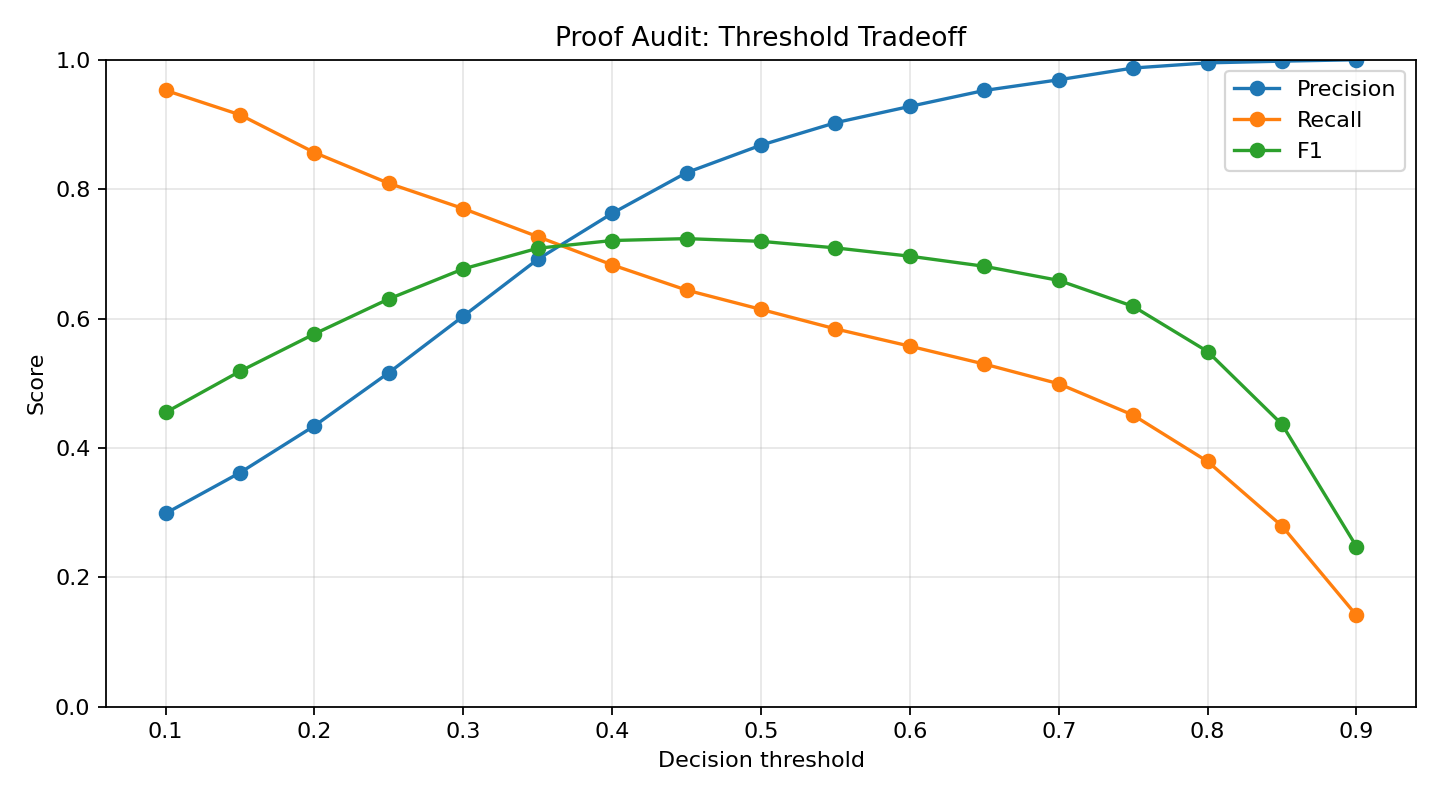

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_calibration_curve.png


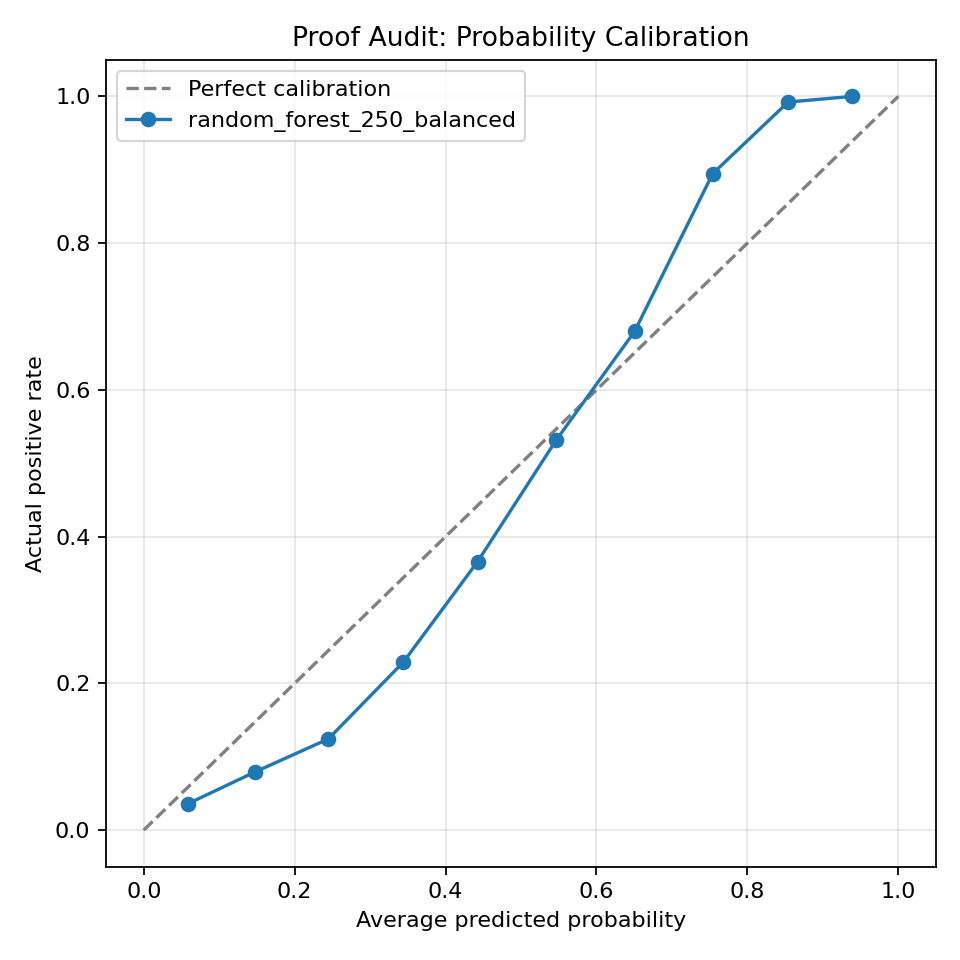

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/proof_circuit_error_profile.png


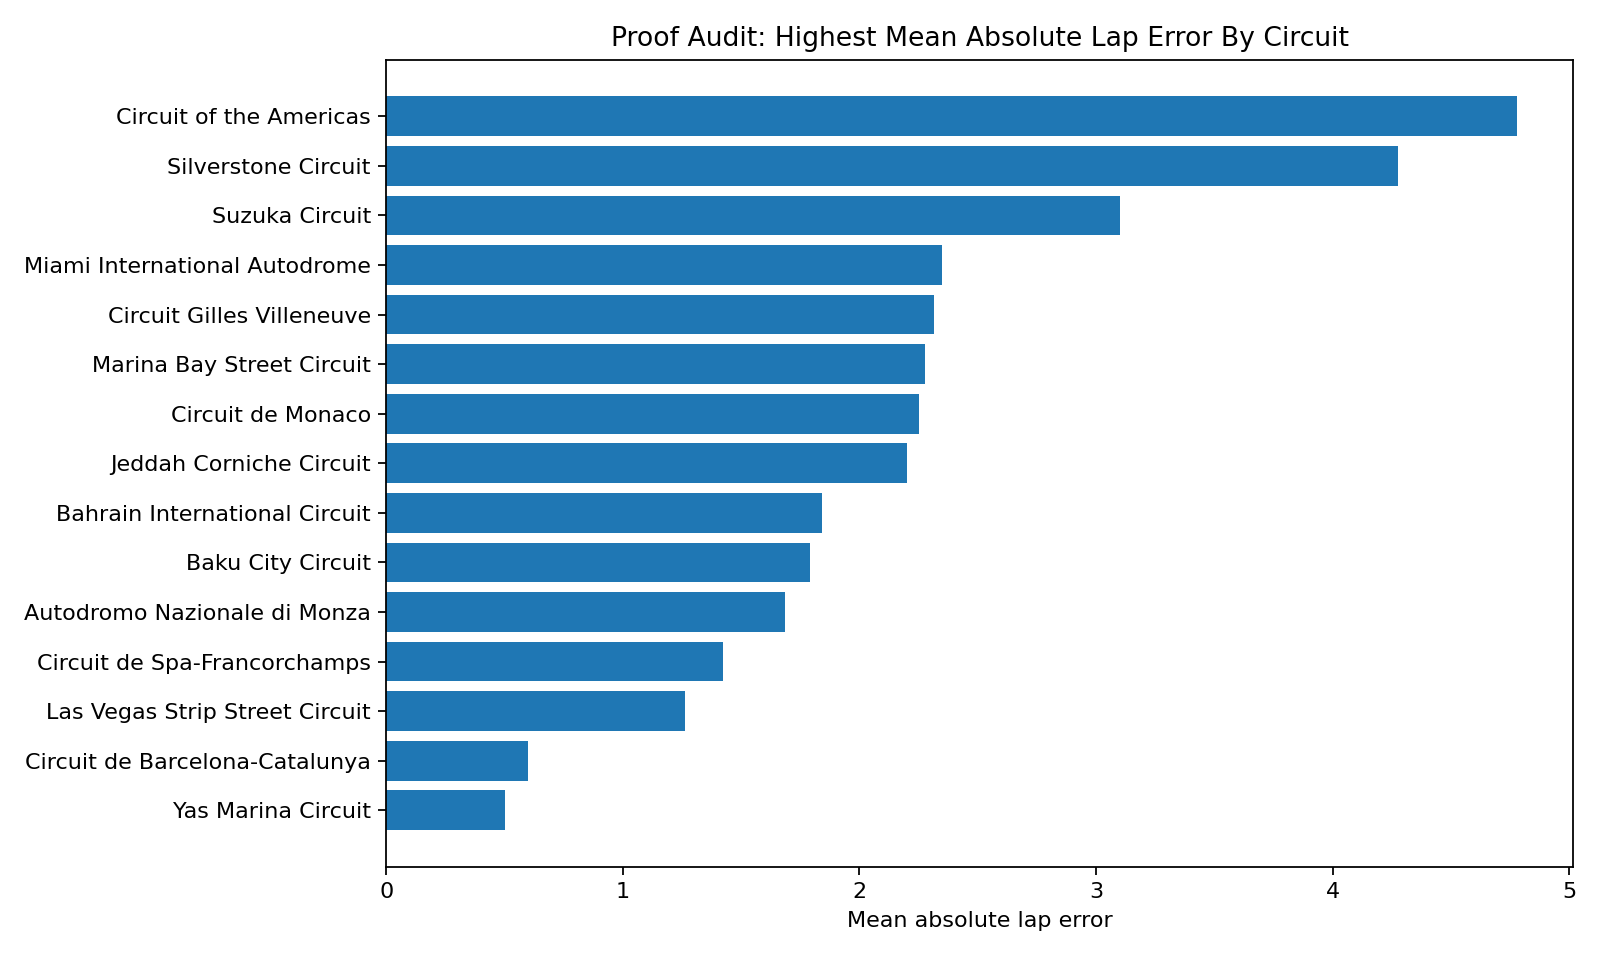

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_learning_curve.png


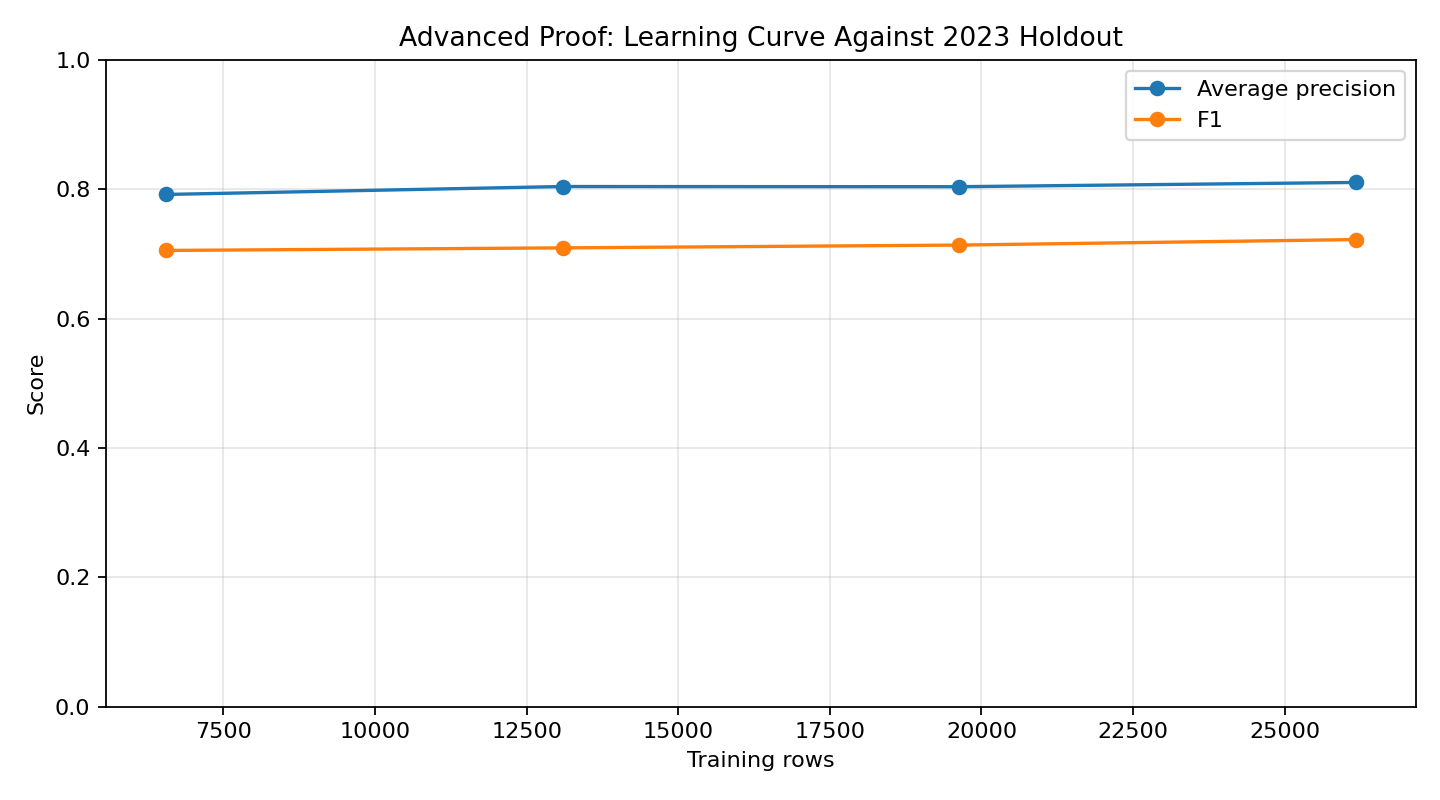

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_robustness_stress_tests.png


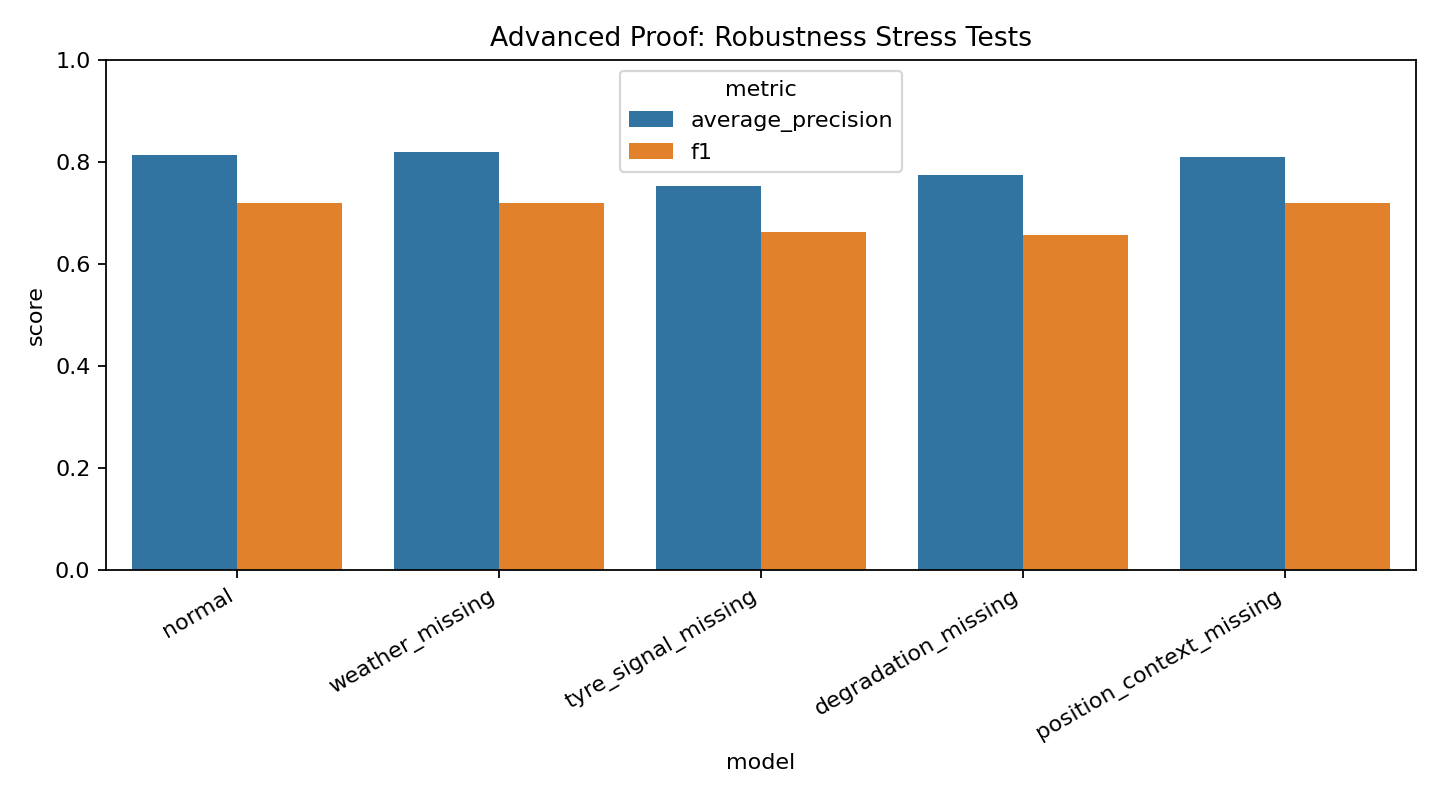

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/advanced_permutation_importance.png


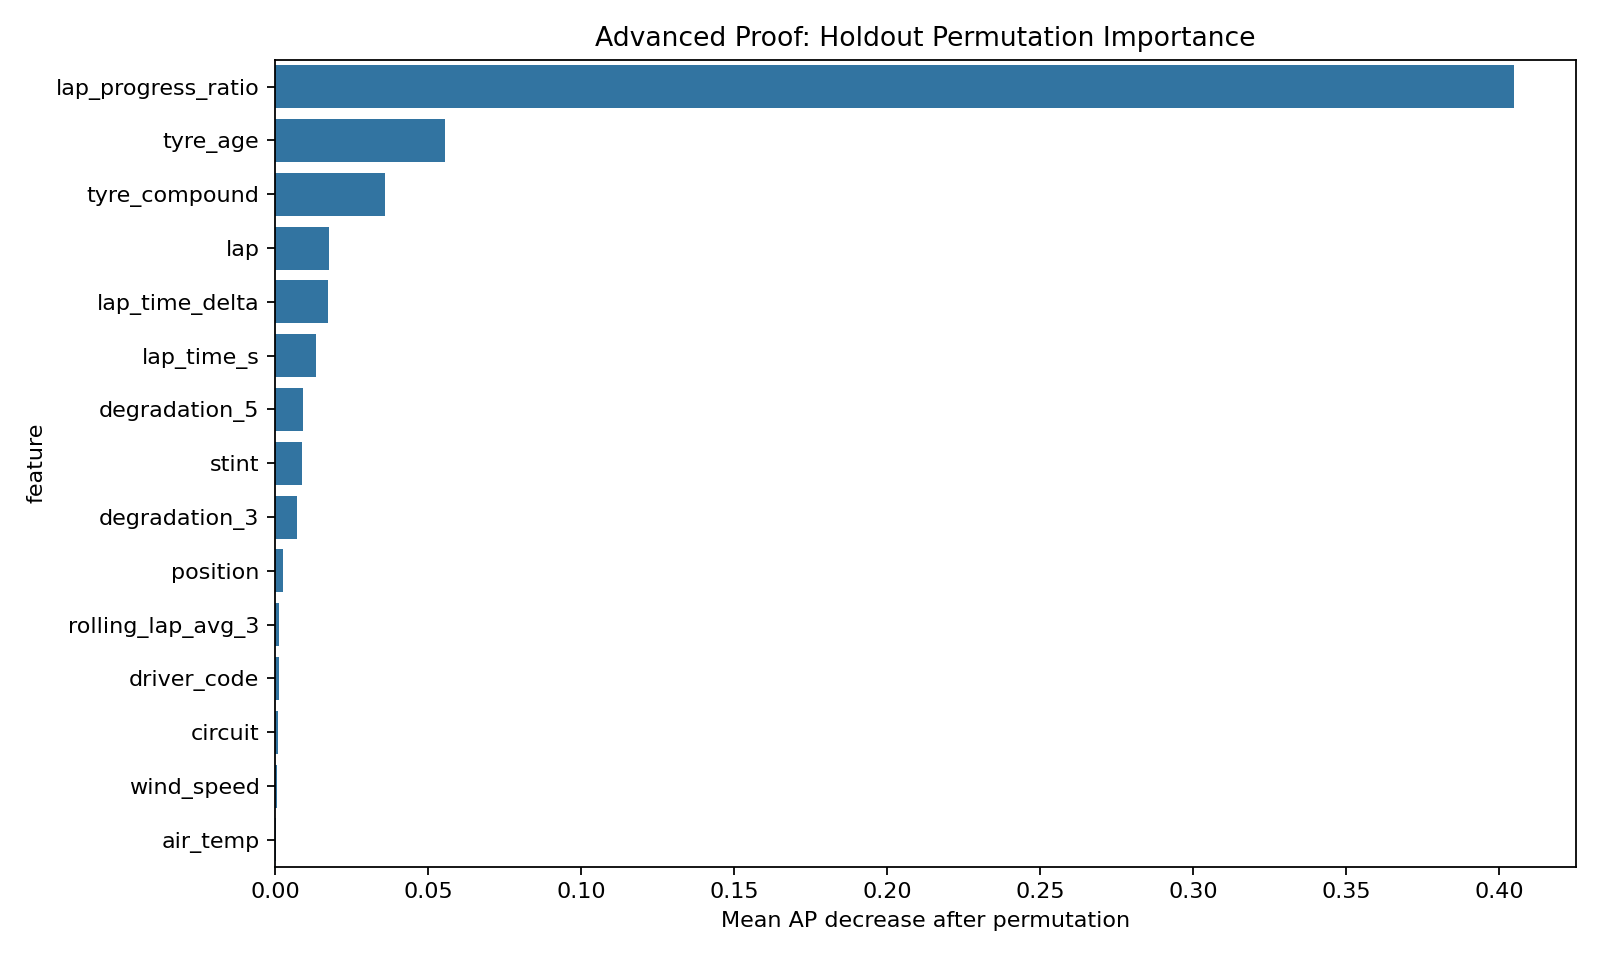

In [6]:
from pathlib import Path
from IPython.display import Markdown, Image, display
import pandas as pd

ROOT = Path('/content/drive/MyDrive/ibm_project_stuff/MDCE')
REPORT_DIR = ROOT / 'outputs' / 'reports'
CHART_DIR = ROOT / 'outputs' / 'charts'
MODEL_DIR = ROOT / 'outputs' / 'models'

print('Best model:', MODEL_DIR / 'pit_window_best_model.joblib')
for report_name in ['advanced_model_hardening.md', 'mdce_proof_quality_audit.md']:
    path = REPORT_DIR / report_name
    if path.exists():
        display(Markdown(path.read_text(encoding='utf-8')))

for csv_name in [
    'advanced_model_leaderboard.csv',
    'proof_threshold_sweep.csv',
    'advanced_temporal_validation.csv',
    'advanced_multi_horizon_metrics.csv',
    'advanced_robustness_stress_tests.csv',
    'advanced_permutation_importance.csv',
]:
    path = REPORT_DIR / csv_name
    if path.exists():
        print('', csv_name)
        display(pd.read_csv(path).head(20))

for chart_name in [
    'proof_threshold_tradeoff.png',
    'proof_calibration_curve.png',
    'proof_circuit_error_profile.png',
    'advanced_learning_curve.png',
    'advanced_robustness_stress_tests.png',
    'advanced_permutation_importance.png',
]:
    path = CHART_DIR / chart_name
    if path.exists():
        print('Chart:', path)
        display(Image(filename=str(path)))
